# GRM Parameter Comparison: mirt vs PyMC

Compares item parameter estimates from:
- **mirt** (R) — `./results/mirt_params.csv`
- **PyMC** (Python) — `./results/pymc_params.csv`

Both are in the GRM threshold parameterisation:
- `a`: discrimination
- `b1` … `b8`: ordered threshold parameters ($b_{jk}$)

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats

In [41]:
mirt  = pd.read_csv("./results/mirt_params.csv")
pymc  = pd.read_csv("./results/pymc_params.csv")

# Align on item column
mirt  = mirt.set_index("item").round(3)
pymc  = pymc.set_index("item").round(3)

items = mirt.index.tolist()
J = len(items)
b_cols = [c for c in mirt.columns if c.startswith("b")]
K_minus1 = len(b_cols)

print(f"Items: {J}   Thresholds per item: {K_minus1}")
print("\nmirt:")
display(mirt.head())
print("\nPyMC:")
display(pymc.head())

Items: 22   Thresholds per item: 8

mirt:


,a,b1,b2,b3,b4,b5,b6,b7,b8
item,,,,,,,,,
Q1,1.570,-1.083,-0.227,0.479,0.783,1.205,1.671,2.409,3.189
Q2,2.445,0.466,0.940,1.189,1.330,1.581,1.858,2.135,2.473
Q3,3.044,0.034,0.496,0.735,0.869,1.038,1.297,1.538,1.845
Q4,2.499,0.219,0.736,0.979,1.076,1.296,1.532,1.820,2.100
Q5,1.918,-0.620,0.126,0.675,1.007,1.376,1.822,2.295,2.898



PyMC:


,a,b1,b2,b3,b4,b5,b6,b7,b8
item,,,,,,,,,
Q1,1.555,-1.104,-0.240,0.473,0.780,1.206,1.677,2.422,3.210
Q2,2.418,0.460,0.938,1.190,1.333,1.586,1.866,2.147,2.490
Q3,3.010,0.023,0.490,0.731,0.867,1.037,1.299,1.543,1.854
Q4,2.473,0.210,0.732,0.977,1.075,1.299,1.537,1.828,2.112
Q5,1.899,-0.637,0.116,0.670,1.006,1.379,1.829,2.307,2.917


## Discrimination parameters ($a_j$)

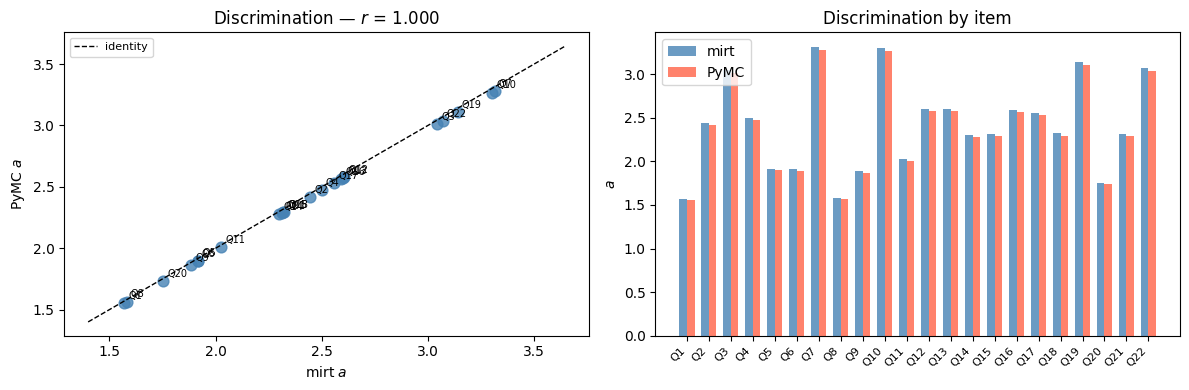

Pearson r = 1.0000, p = 2.8938e-55


In [42]:
a_mirt = mirt["a"].values
a_pymc = pymc["a"].values

r, pval = stats.pearsonr(a_mirt, a_pymc)
lo = min(a_mirt.min(), a_pymc.min()) * 0.9
hi = max(a_mirt.max(), a_pymc.max()) * 1.1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter
ax = axes[0]
ax.scatter(a_mirt, a_pymc, s=60, alpha=0.8, color="steelblue")
for i, item in enumerate(items):
    ax.annotate(item, (a_mirt[i], a_pymc[i]), fontsize=7,
                xytext=(3, 3), textcoords="offset points")
ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")
ax.set_xlabel("mirt $a$")
ax.set_ylabel("PyMC $a$")
ax.set_title(f"Discrimination — $r$ = {r:.3f}")
ax.legend(fontsize=8)

# Bar comparison
ax = axes[1]
x = np.arange(J)
w = 0.35
ax.bar(x - w/2, a_mirt, w, label="mirt",  color="steelblue", alpha=0.8)
ax.bar(x + w/2, a_pymc, w, label="PyMC", color="tomato",    alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(items, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("$a$")
ax.set_title("Discrimination by item")
ax.legend()

plt.tight_layout()
plt.show()
print(f"Pearson r = {r:.4f}, p = {pval:.4e}")

## Threshold parameters ($b_{jk}$)

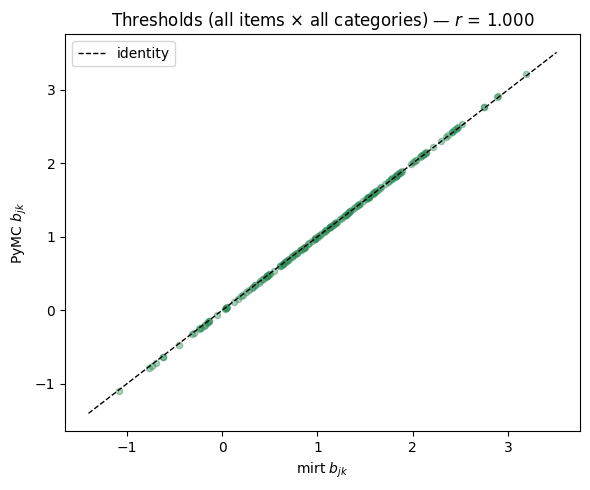

Pearson r = 1.0000, p = 0.0000e+00


In [43]:
b_mirt = mirt[b_cols].values.ravel()   # (J * (K-1),)
b_pymc = pymc[b_cols].values.ravel()

r_b, pval_b = stats.pearsonr(b_mirt, b_pymc)
lo_b = min(b_mirt.min(), b_pymc.min()) - 0.3
hi_b = max(b_mirt.max(), b_pymc.max()) + 0.3

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(b_mirt, b_pymc, s=20, alpha=0.4, color="seagreen")
ax.plot([lo_b, hi_b], [lo_b, hi_b], "k--", lw=1, label="identity")
ax.set_xlabel("mirt $b_{jk}$")
ax.set_ylabel("PyMC $b_{jk}$")
ax.set_title(f"Thresholds (all items × all categories) — $r$ = {r_b:.3f}")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Pearson r = {r_b:.4f}, p = {pval_b:.4e}")

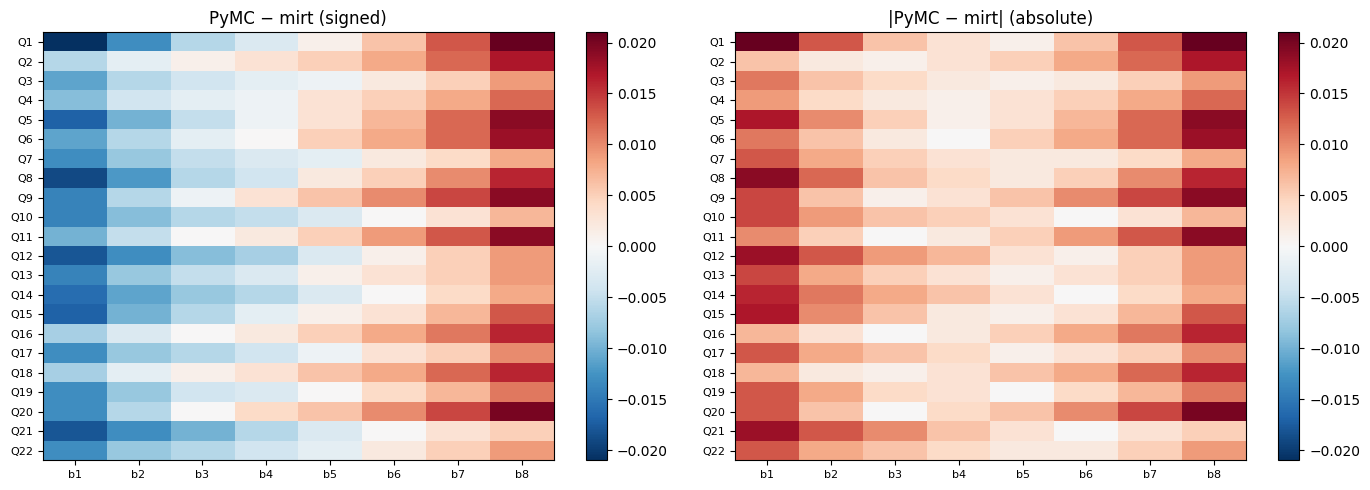

In [44]:
diff_b = pymc[b_cols].values - mirt[b_cols].values  # (J, K-1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vmax = np.abs(diff_b).max()

for ax, data, title in zip(
    axes,
    [diff_b, np.abs(diff_b)],
    ["PyMC − mirt (signed)", "|PyMC − mirt| (absolute)"],
):
    im = ax.imshow(data, aspect="auto", cmap="RdBu_r",
                   vmin=-vmax, vmax=vmax)
    ax.set_yticks(range(J))
    ax.set_yticklabels(items, fontsize=8)
    ax.set_xticks(range(K_minus1))
    ax.set_xticklabels([f"b{k+1}" for k in range(K_minus1)], fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

## Summary statistics

In [45]:
summary = pd.DataFrame({
    "param":  ["a"] + b_cols,
    "r":      [stats.pearsonr(mirt[p].values, pymc[p].values)[0] for p in ["a"] + b_cols],
    "MAE":    [np.mean(np.abs(pymc[p].values - mirt[p].values)) for p in ["a"] + b_cols],
    "RMSE":   [np.sqrt(np.mean((pymc[p].values - mirt[p].values)**2)) for p in ["a"] + b_cols],
    "bias":   [np.mean(pymc[p].values - mirt[p].values) for p in ["a"] + b_cols],
})
summary = summary.set_index("param").round(4)
display(summary)
print(f"\nOverall a  — r={r:.4f}  MAE={np.mean(np.abs(a_pymc-a_mirt)):.4f}")
print(f"Overall b  — r={r_b:.4f}  MAE={np.mean(np.abs(b_pymc-b_mirt)):.4f}")

,r,MAE,RMSE,bias
param,,,,
a,1.0,0.0252,0.0259,-0.0252
b1,1.0,0.0134,0.0139,-0.0134
b2,1.0,0.0078,0.0085,-0.0078
b3,1.0,0.0042,0.0051,-0.0040
b4,1.0,0.0032,0.0036,-0.0017
b5,1.0,0.0030,0.0036,0.0014
b6,1.0,0.0047,0.0058,0.0047
b7,1.0,0.0084,0.0092,0.0084
b8,1.0,0.0132,0.0141,0.0132



Overall a  — r=1.0000  MAE=0.0252
Overall b  — r=1.0000  MAE=0.0072
